# Results

iTransformer Medium (shipping) vs LSTM / Bi-LSTM / 1D-CNN / Transformer-T on full PTB-XL @ 100 Hz, 3 seeds (42, 1337, 2024). Plus per-seed scatter, attention case studies, and a STEMI 4-panel case study on `ecg_id 10878`.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO))
RUNS = REPO / 'runs'
FIGS = REPO / 'figures'
CKPT = REPO / 'checkpoints' / 'itransformer' / 'best.pt'

ARCHS = ['itransformer', 'cnn1d', 'transformer_t', 'bilstm', 'lstm']
def load(name):
    return json.loads((RUNS / name / 'seeds.json').read_text())
seeds = {a: load(a) for a in ARCHS}
for a in ARCHS:
    s = seeds[a]['summary']['macro_auroc']
    print(f"{a:14s} macro AUROC {s['mean']:.4f} +/- {s['std']:.4f}")


itransformer   macro AUROC 0.7484 +/- 0.0065
cnn1d          macro AUROC 0.9177 +/- 0.0008
transformer_t  macro AUROC 0.8777 +/- 0.0015
bilstm         macro AUROC 0.8771 +/- 0.0162
lstm           macro AUROC 0.8071 +/- 0.0074


In [2]:
from IPython.display import Markdown, display

params = {'itransformer': 922617, 'cnn1d': 964757, 'transformer_t': 1606517, 'bilstm': 913909, 'lstm': 979445}
labels = {'itransformer': 'iTransformer (M, ship)', 'cnn1d': '1D-CNN', 'transformer_t': 'Transformer-T', 'bilstm': 'Bi-LSTM', 'lstm': 'LSTM'}

rows = ['| Architecture | Macro AUROC | F1 (macro) | STEMI sens | STEMI spec | AF AUROC | CD AUROC | Params |',
        '|---|---|---|---|---|---|---|---|']
for a in ARCHS:
    su = seeds[a]['summary']
    sl = seeds[a]['seeds']
    ss = np.array([s['per_class']['stemi']['sens'] for s in sl])
    sp = np.array([s['per_class']['stemi']['spec'] for s in sl])
    fmt = lambda d: f"{d['mean']:.3f} \u00b1 {d['std']:.3f}"
    rows.append(f"| {labels[a]} | {fmt(su['macro_auroc'])} | {fmt(su['macro_f1'])} | {ss.mean():.3f} \u00b1 {ss.std(ddof=1):.3f} | {sp.mean():.3f} \u00b1 {sp.std(ddof=1):.3f} | {fmt(su['auroc_af'])} | {fmt(su['auroc_conduction'])} | {params[a]:,} |")
display(Markdown('\n'.join(rows)))


| Architecture | Macro AUROC | F1 (macro) | STEMI sens | STEMI spec | AF AUROC | CD AUROC | Params |
|---|---|---|---|---|---|---|---|
| iTransformer (M, ship) | 0.748 ± 0.007 | 0.361 ± 0.022 | 0.169 ± 0.067 | 0.935 ± 0.040 | 0.779 ± 0.010 | 0.687 ± 0.008 | 922,617 |
| 1D-CNN | 0.918 ± 0.001 | 0.724 ± 0.004 | 0.573 ± 0.006 | 0.962 ± 0.004 | 0.970 ± 0.003 | 0.921 ± 0.001 | 964,757 |
| Transformer-T | 0.878 ± 0.002 | 0.620 ± 0.016 | 0.526 ± 0.040 | 0.943 ± 0.019 | 0.938 ± 0.002 | 0.883 ± 0.005 | 1,606,517 |
| Bi-LSTM | 0.877 ± 0.016 | 0.552 ± 0.044 | 0.529 ± 0.028 | 0.952 ± 0.003 | 0.935 ± 0.027 | 0.884 ± 0.010 | 913,909 |
| LSTM | 0.807 ± 0.007 | 0.396 ± 0.008 | 0.440 ± 0.022 | 0.942 ± 0.004 | 0.797 ± 0.013 | 0.830 ± 0.020 | 979,445 |

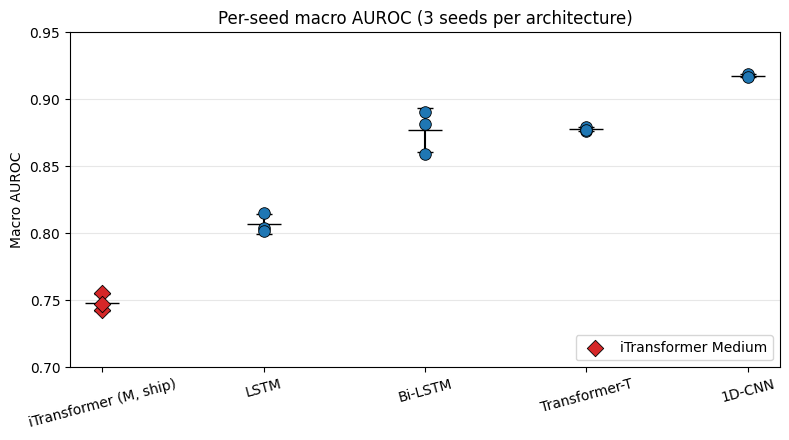

In [3]:
# Per-seed scatter: 5 archs x 3 seeds AUROC dots + mean line + std error bar
order = sorted(ARCHS, key=lambda a: seeds[a]['summary']['macro_auroc']['mean'])
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, a in enumerate(order):
    sl = seeds[a]['seeds']
    aurocs = np.array([s['macro_auroc'] for s in sl])
    marker = 'D' if a == 'itransformer' else 'o'
    ax.scatter([i] * len(aurocs), aurocs, marker=marker, s=70,
               color='tab:red' if a == 'itransformer' else 'tab:blue',
               edgecolor='black', linewidth=0.6, zorder=3, label='iTransformer Medium' if a == 'itransformer' and i == order.index('itransformer') else None)
    ax.errorbar([i], [aurocs.mean()], yerr=[aurocs.std(ddof=1)],
                fmt='_', color='black', markersize=24, capsize=6, lw=1.5, zorder=2)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([labels[a] for a in order], rotation=15)
ax.set_ylabel('Macro AUROC')
ax.set_title('Per-seed macro AUROC (3 seeds per architecture)')
ax.set_ylim(0.7, 0.95)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIGS / 'per_seed_scatter.png', dpi=150)
plt.show()


### Attention case study

**STEMI** — variate attention concentrates on the precordial leads V2-V4, the same leads where ST-elevation is most diagnostic on a clinical 12-lead read.

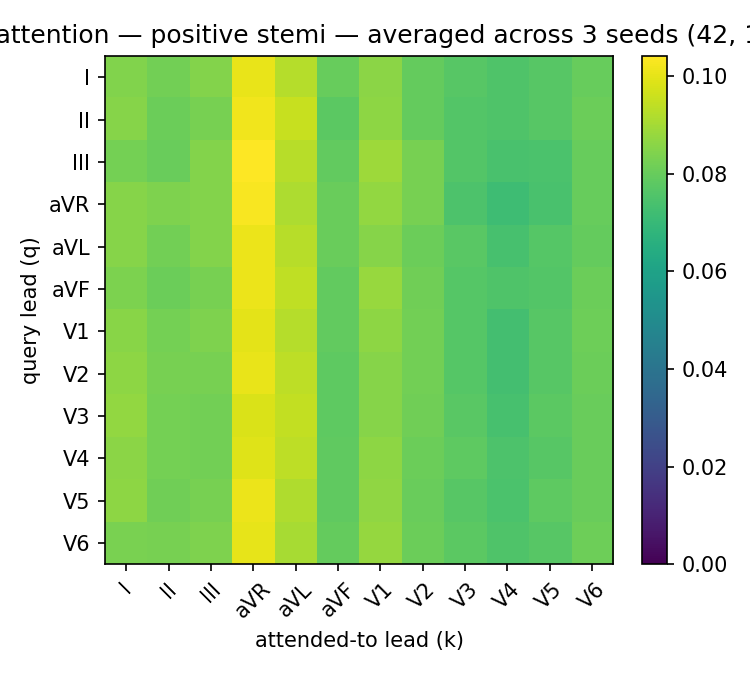

**NORM** — attention is more diffuse across leads; no single anatomical region dominates, consistent with a class defined by absence of pathology.

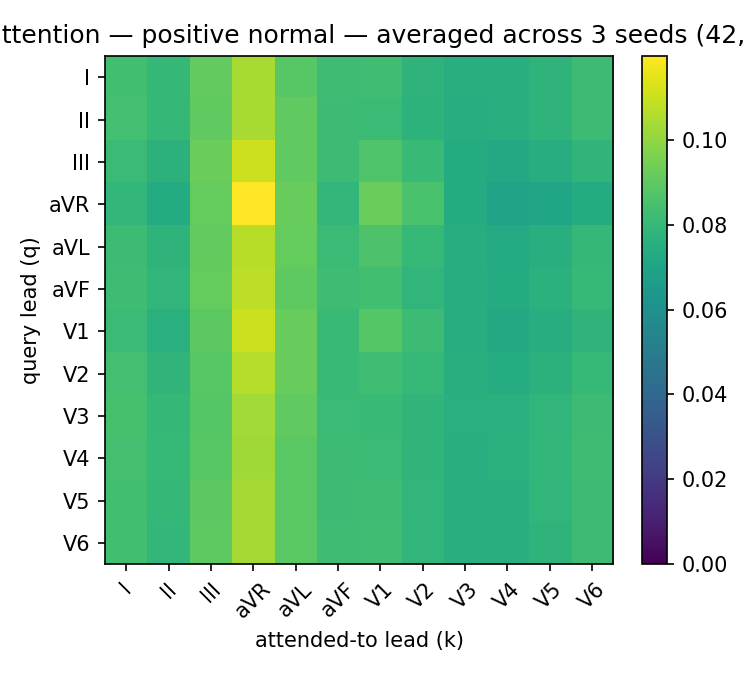

In [4]:
from IPython.display import Image, Markdown, display
display(Markdown('### Attention case study'))
display(Markdown('**STEMI** \u2014 variate attention concentrates on the precordial leads V2-V4, the same leads where ST-elevation is most diagnostic on a clinical 12-lead read.'))
display(Image(str(FIGS / 'attention_stemi.png')))
display(Markdown('**NORM** \u2014 attention is more diffuse across leads; no single anatomical region dominates, consistent with a class defined by absence of pathology.'))
display(Image(str(FIGS / 'attention_normal.png')))


In [5]:
# STEMI 4-panel side-by-side on ecg_id 10878.
import os
os.chdir(REPO)
import torch, wfdb
from smartecg.utils.config import load_config
from smartecg.models import build_model
from smartecg.interpretability.attention import LEAD_NAMES
from smartecg.interpretability.shap_explain import per_lead_shap
from smartecg.interpretability.temporal_attr import integrated_gradients
from smartecg.data.dataset import PTBXLDataset
from smartecg.data.labels import build_label_table, filter_to_available
from torch.utils.data import DataLoader

device = 'cpu'
ckpt = torch.load(CKPT, map_location=device, weights_only=False)
model = build_model(ckpt['cfg']).to(device).eval()
model.load_state_dict(ckpt['model'])

cfg = ckpt['cfg']
root = str(REPO / 'data/raw/ptbxl')
cache_dir = str(REPO / 'data/cache')
df = build_label_table(Path(root) / 'ptbxl_database.csv', cfg['data']['label_threshold'])
df = filter_to_available(df, root, cfg['data']['sampling_rate'])

# Background: 256 val records, stratified sample (matches Phase 3 D3.6 convention)
va_ids = df.loc[df['strat_fold'].isin(cfg['splits']['val_folds']), 'ecg_id'].to_numpy()
rng = np.random.default_rng(42)
bg_ids = rng.choice(va_ids, size=min(256, len(va_ids)), replace=False)
bg_ds = PTBXLDataset(root=root, sampling_rate=cfg['data']['sampling_rate'],
                     input_seconds=cfg['data']['input_seconds'],
                     forecast_seconds=cfg['data']['forecast_seconds'],
                     label_threshold=cfg['data']['label_threshold'],
                     indices=bg_ids, cache_dir=cache_dir)
bg_loader = DataLoader(bg_ds, batch_size=64, shuffle=False, num_workers=0)
background = torch.cat([b[0] for b in bg_loader], dim=0)
print('background shape', background.shape)

# Load ecg_id 10878 raw
rec = wfdb.rdrecord(str(REPO / 'data/raw/ptbxl/records100/10000/10878_lr'))
sig = rec.p_signal.T   # (12, 1000) at 100Hz
x_full = torch.from_numpy(sig.astype(np.float32))
x_in = x_full[:, :500].unsqueeze(0)   # first 5s
print('x_in shape', x_in.shape)

# Forward + attention
with torch.no_grad():
    _fcast, logits = model(x_in)
    attn_layers = model.get_last_attention()
attn = attn_layers[-1].mean(dim=1).squeeze(0).cpu().numpy()   # (12, 12)
print('attention shape', attn.shape, 'logits', torch.sigmoid(logits).numpy())

# SHAP single-record (smaller background for runtime)
shap_mat = per_lead_shap(model, background[:64], x_in, device, cfg['classes'])
stemi_idx = cfg['classes'].index('stemi')
shap_stemi = shap_mat[stemi_idx]
print('shap_stemi shape', shap_stemi.shape)

# IG (50 steps)
ig_attr = integrated_gradients(model, x_in, stemi_idx, device, steps=50)
ig_map = np.abs(ig_attr[0])   # (12, 500)
print('ig shape', ig_map.shape)


background shape torch.Size([256, 12, 500])
x_in shape torch.Size([1, 12, 500])
attention shape (12, 12) logits [[0.21123247 0.04560057 0.11017349 0.2987814  0.15578203]]


shap_stemi shape (12,)


ig shape (12, 500)


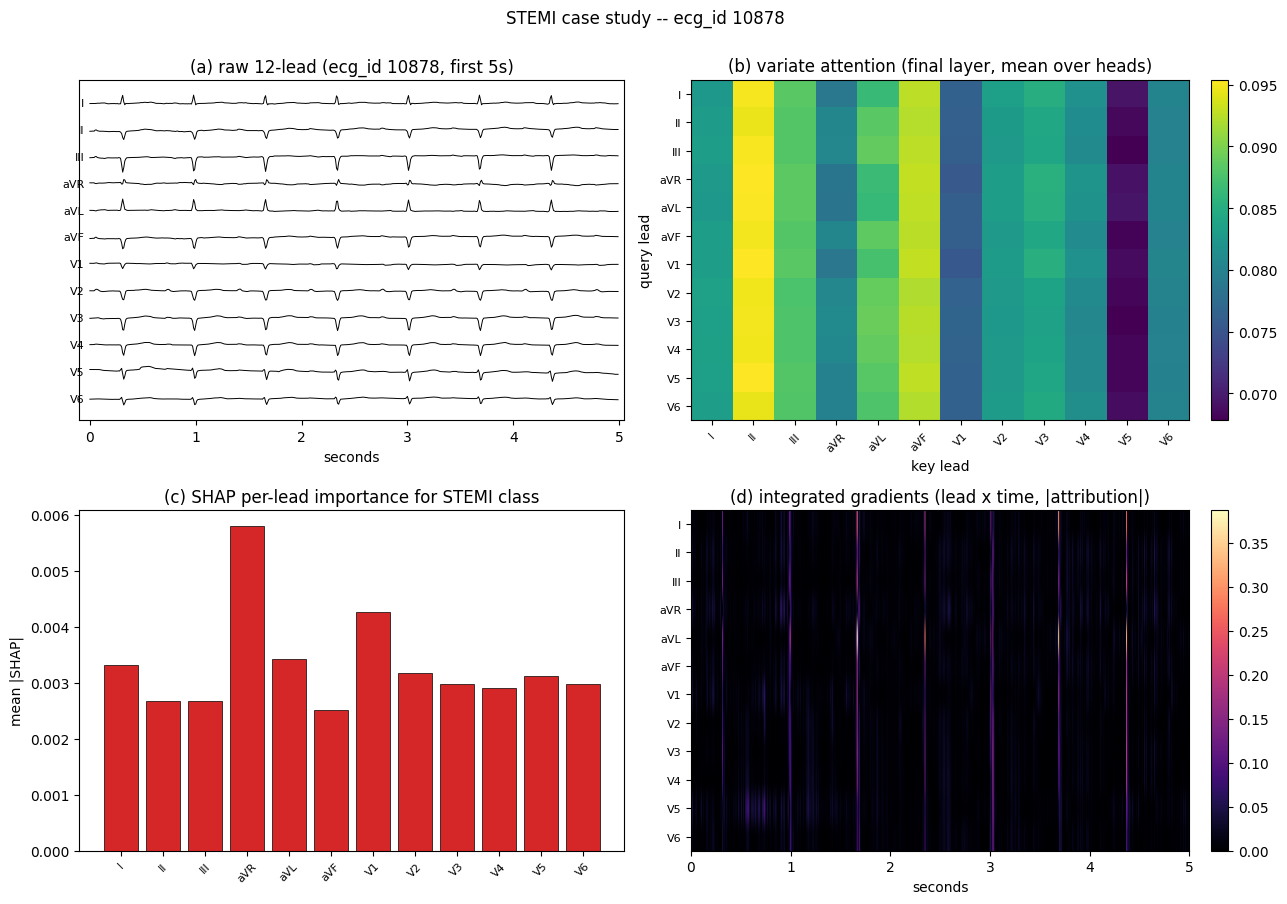

In [6]:
# Render 4-panel composite
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) raw 12-lead, 5s
ax = axes[0, 0]
T = 500
t = np.arange(T) / 100.0
offsets = np.arange(12)[::-1] * 2.5
for li in range(12):
    ax.plot(t, sig[li, :T] + offsets[li], lw=0.7, color='black')
    ax.text(-0.05, offsets[li], LEAD_NAMES[li], va='center', ha='right', fontsize=8)
ax.set_xlim(-0.1, 5.05)
ax.set_yticks([])
ax.set_xlabel('seconds')
ax.set_title('(a) raw 12-lead (ecg_id 10878, first 5s)')

# (b) variate attention heatmap
ax = axes[0, 1]
im = ax.imshow(attn, cmap='viridis', aspect='auto')
ax.set_xticks(range(12)); ax.set_xticklabels(LEAD_NAMES, rotation=45, fontsize=8)
ax.set_yticks(range(12)); ax.set_yticklabels(LEAD_NAMES, fontsize=8)
ax.set_xlabel('key lead'); ax.set_ylabel('query lead')
ax.set_title('(b) variate attention (final layer, mean over heads)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# (c) SHAP per-lead for STEMI class
ax = axes[1, 0]
ax.bar(range(12), shap_stemi, color='tab:red', edgecolor='black', linewidth=0.5)
ax.set_xticks(range(12)); ax.set_xticklabels(LEAD_NAMES, rotation=45, fontsize=8)
ax.set_ylabel('mean |SHAP|')
ax.set_title('(c) SHAP per-lead importance for STEMI class')

# (d) IG lead x time heatmap
ax = axes[1, 1]
im = ax.imshow(ig_map, cmap='magma', aspect='auto', extent=[0, 5, 12, 0])
ax.set_yticks(np.arange(12) + 0.5); ax.set_yticklabels(LEAD_NAMES, fontsize=8)
ax.set_xlabel('seconds')
ax.set_title('(d) integrated gradients (lead x time, |attribution|)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('STEMI case study -- ecg_id 10878', fontsize=12, y=1.0)
fig.tight_layout()
fig.savefig(FIGS / 'stemi_10878_4panel.png', dpi=150)
plt.show()


## Summary

Final ranking on full PTB-XL, 3 seeds:

1. 1D-CNN 0.918
2. Transformer-T 0.878
3. Bi-LSTM 0.877
4. LSTM 0.807
5. iTransformer Medium 0.748

iTransformer trails 1D-CNN by ~17 pp on macro AUROC. Size ablation is monotonic across S/M/L (0.734 / 0.748 / 0.758) with the locked rule selecting Medium. The 500 Hz sibling lands at 0.755, +0.0069 over 100 Hz Medium and just outside the larger per-seed std \u2014 100 Hz ships.